## Process SFNO data for selected flooding events

- Useful data locations on s3
    - Desmond simulation initialised at 00Z on 23 Nov 2015 (34 checkpoints): `s3://jba-stress-testing/desmond/global/`
    - Desmond different initialisation times: `s3://jba-stress-testing/event_response/global/`
    - TC Charley from October 1986: `s3://jba-stress-testing/charley_1986/global/`
    - August 2015 non-event (looking for events that plausibly could have happened): `s3://jba-stress-testing/dublin_2015/global/` 

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
sns.set_theme()
import logging
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import re
import os
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import plotting_functions as pf

## Process the files if needed 

- Read in data from the config file
- Create UK-Ireland subset from global input files 
- MUCH faster with ncks command - avoid using xarray
- `for s in $seeds; do` 
    - `ncks -v tp06,msl,u10m,v10m,t2m -d lat,46,62 -d lon,-14,8 stress_testing_2015-11-23T00_pkg_seed${s}.nc desmond_2015-11-23T00_pkg_seed${s}.nc;` 
- `done`

In [ ]:
config_file_path = '/mnt/data/data_analysis/config.json'
events = pf.load_config(config_file_path)
event_str = 'Desmond_seed76_v2' # ['21Aug2015', '22Aug2015', 'Charley_20Aug1986', 'Desmond', 'Desmond_seed76', 'event_response'] 
file_path = events[event_str]['path']
files = sorted(glob.glob(f'{file_path}/*.nc'))
date_str = events[event_str]['date_str']
event_name = events[event_str]['name']

location = 'Dublin'
if location == 'Dublin':
    lat0, lat1, lon0, lon1 = 53.5, 53.0, -6.9, -6.1
elif location == 'Cumbria':
    lat0, lat1, lon0, lon1 = 54.8, 54.2, -3.2, -2.4
else:
    raise Exception('location not yet set up...')

def global_to_regional_nc(file_path: str) -> xr.Dataset:
    """
    Create a regional nc file from a global input file  
    """

    # file_path = '/mnt/data/sfno/Desmond_seed76/stress-testing_2015-11-18T00_pkg_seed76.nc'
    # uk_bbox = [75.0, 15.0, -60, 30]
    # lat0, lat1, lon0, lon1 = uk_bbox
    # for file in files:
    #     #date_str = file.split('/')[6].split('_')[2]
    #     ds = xr.open_dataset(file,
    #                          engine='netcdf4',
    #                         #  chunks={'lat': 80, 'lon': 80},
    #                          decode_times=False,
    #                          mask_and_scale=False,
    #                          use_cftime=False,
    #                          cache=False)
    #     ds = ds.assign_coords(lon=((ds.lon + 180) % 360 - 180)).sortby('lon')
    #     ds = ds.sel(lat=slice(lat0, lat1),lon=slice(lon0, lon1))

    #     outpath = f'/mnt/data/sfno/Desmond_seed76/stress-testing_2015-11-18T00_pkg_seed76_subset.nc'
    #     logging.info("Saving output to %s", outpath)
    #     encoding = {var: {"zlib": True, "complevel": 4} for var in ds.data_vars}
    #     ds.to_netcdf(outpath, format="NETCDF4", encoding=encoding)
    #     logging.info("Saved %s", outpath)

### Code below only works for `event_str` == `Desmond` (rather than `Desmond_seed76`)

In [158]:
# # apply the pre-processing function if we need to create a multi-index dimension to merge the seed + ensemble member information
# # required when we have multiple input files (/mnt/data/sfno/Desmond/) but not with a single input file (/mnt/data/sfno/Desmond_seed76/)
# da_pr_all, da_mslp_all = preprocess_input_nc_files(files,
#                                                    rolling_window=4,
#                                                    min_periods=4,
#                                                    event_str=event_str,
#                                                    lead_dim='lead_time')

# # get readable labels using the 'seed' and 'ensemble' information from the index that we've created 
# ### This code is only relevant when we create a MultiIndex dimension from 'seed' and 'ensemble' 
# sample_index = da_pr_all['member'].to_index()  # Index of (time, ensemble) tuples
# seeds = sorted({int(s) for s, e in sample_index})
# num_seeds = len(seeds)

# da_pr_all

## Plot the rolling 24-h accumulated rainfall using the new `seed76` ensemble forecast 

- `TODO`: combine this code with the plotting code in the next couple of cells to make a single function that accounts for different dimensions/coordinates 
- Calculate rolling 24-h accumulated rainfall 
- 

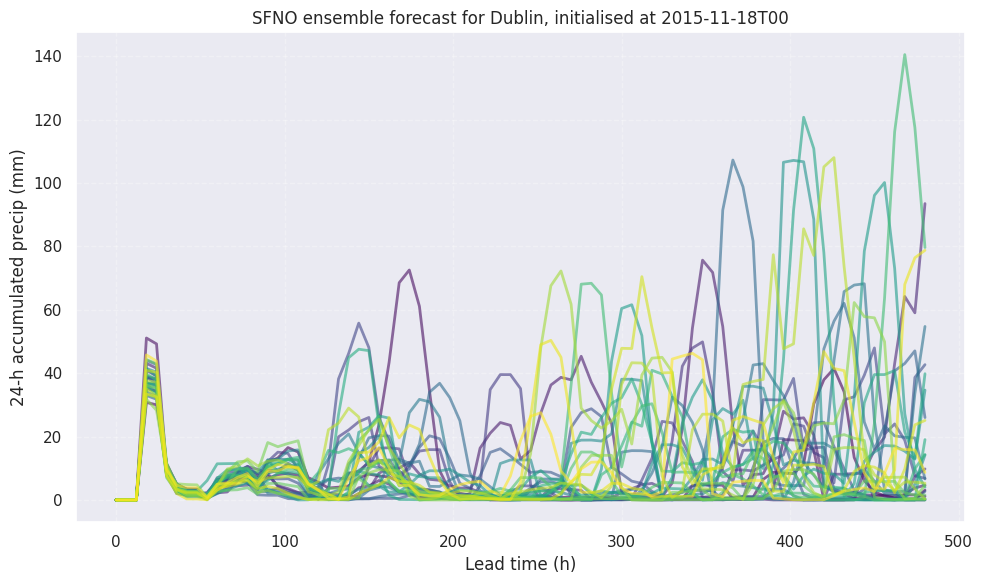

In [ ]:
# open the file that we created using the 'global_to_regional_nc' function above 
da_pr24, da_mslp = pf.preprocess_input_nc_files(files,
                                                rolling_window=4,
                                                min_periods=4,
                                                event_str=event_str,
                                                lead_dim='lead_time')

# define other metadata and relevant information
metric = '24h-sum'

# plotting colours 
cmap = plt.get_cmap('viridis')
num_fcsts = len(da_pr24.member)
ensembles = da_pr24.member.values
fcst_to_colour = {ens: cmap(i/(num_fcsts-1)) for i, ens in enumerate(ensembles)}

if metric == '24h-sum':
    ds = da_pr24.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
elif metric == '24h-mean':
    ds = da_pr24.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])

fig, ax = plt.subplots(figsize=(10,6))
if event_str == 'Desmond_seed76' or event_str == 'Desmond_seed76_v2':
    for i, ens in enumerate(ensembles):
        colour = fcst_to_colour[int(ens)]
        y = ds.isel(member=i).values  # dependent variable (y axis) values 
        x = ds.lead_time.values  # independent variable (x axis --> time) values
        ax.plot(x, y, color=colour, alpha=0.6, linewidth=2)
elif event_str == 'Desmond': # TODO: edit the code below to run succesfully using the different input file structure (index = seed x ensemble)
    for i, ens in enumerate(ensembles):
        colour = fcst_to_colour[int(ens)]
        y = ds.isel(member=i).values  # dependent variable (y axis) values 
        x = ds.lead_time.values  # independent variable (x axis --> time) values
        ax.plot(x, y, color=colour, alpha=0.6, linewidth=2)  # mark every 4 points

# add background grid 
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlabel('Lead time (h)')
ax.set_ylabel('24-h accumulated precip (mm)')
ax.set_title(f'SFNO ensemble forecast for {location}, initialised at {date_str}')
plt.tight_layout()

out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_{date_str}_SFNO_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Plot the rolling 24-h accumulated rainfall 

- Slightly different to the original 6-h code because we've already pre-processed the input files
- START FROM HERE

In [49]:
# # apply the pre-processing function if we need to create a multi-index dimension to merge the seed + ensemble member information
# # required when we have multiple input files (/mnt/data/sfno/Desmond/) but not with a single input file (/mnt/data/sfno/Desmond_seed76/)
# da_mslp_all, da_pr_all = preprocess_input_nc_files(files)

# # get readable labels using the 'seed' and 'ensemble' information from the index that we've created 
# ### This code is only relevant when we create a MultiIndex dimension from 'seed' and 'ensemble' 
# sample_index = da_pr_all['member'].to_index()  # Index of (time, ensemble) tuples
# seeds = sorted({int(s) for s, e in sample_index})
# num_seeds = len(seeds)

# cmap = plt.get_cmap('viridis')
# seed_to_colour = {seed: cmap(i/(num_seeds-1)) for i, seed in enumerate(seeds)}

# # define 4 distinct member styles
# member_styles = [
#     dict(linestyle='-',  marker='o', markersize=4),
#     dict(linestyle='--', marker='s', markersize=4),
#     dict(linestyle='-.', marker='^', markersize=4),
#     dict(linestyle=':',  marker='v', markersize=4),
# ]


# metric = '24h-sum'
# date_expr = events[event_str]['date_expr']
# da_pr24 = da_pr_all.rolling(lead_time=4,min_periods=4).sum().dropna('lead_time')

# if metric == '24h-sum':
#     ds = da_pr24.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
# elif metric == '24h-mean':
#     ds = da_pr24.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])

# fig, ax = plt.subplots(figsize=(10,6))
# for i, (seed, member) in enumerate(sample_index):
#     colour = seed_to_colour[int(seed)]
#     style = member_styles[int(member) % len(member_styles)]
#     y = ds.isel(member=i).values  # dependent variable (y axis) values 
#     x = ds.lead_time.values  # independent variable (x axis --> time) values
#     ax.plot(x, y, color=colour, alpha=0.6 if style['linestyle']!=':' else 0.9,
#             linewidth=0.9, **style, markevery=4)  # mark every 4 points

# # # 3) build compact legends: one for seeds (colour) and one for member styles
# # # seed legend (show a subset or all; for many seeds show e.g. first/last/important only)
# # seed_handles = [Line2D([0],[0], color=seed_to_colour[s], lw=3) for s in seeds[:8]]  # show 8 sample seeds
# # seed_labels  = [f"seed{s}" for s in seeds[:8]]
# # legend1 = ax.legend(seed_handles, seed_labels, title='Seed (sample)', loc='upper left', bbox_to_anchor=(1.02,1))

# # # member (linestyle) legend
# # member_handles = [Line2D([0],[0], color='k', lw=1.5, **member_styles[m]) for m in range(4)]
# # member_labels  = [f'ensemble {m}' for m in range(4)]
# # legend2 = ax.legend(member_handles, member_labels, title='Member', loc='upper left', bbox_to_anchor=(1.02,0.6))
# #ax.add_artist(legend1)  # keep both legends

# # add background grid 
# ax.grid(True, linestyle='--', alpha=0.3)

# ax.set_xlabel('Lead time (h)')
# ax.set_ylabel('24-h accumulated precip (mm)')
# ax.set_title(f'SFNO ensemble forecast for {location}, initialised at {date_expr}')
# plt.tight_layout()

# plt.show()

## Process dataset to identify the top `N` most extreme forecasts before plotting

- Input: 2D array (`lead_time`, `member`/`ensemble`) after calculating the sum over the input grid box (e.g. Dublin)
- Calculate the maximum value for each ensemble member at any lead time

In [ ]:
region_extent = [lon0, lon1, lat1, lat0]  # [west, east, north, south]
da_plot, all_member_values, top5_member_inds, top5_member_colours, sample_index = pf.identify_top_n_forecasts(da_pr24,
                                                                                                              event_str=event_str,
                                                                                                              region_extent=region_extent,
                                                                                                              cmap='viridis',
                                                                                                              top_num=5)

## Highlight the most extreme forecasts in bold 

- Produce a plot similar to the previous one, but with the top 5 most `extreme` forecasts highlighted

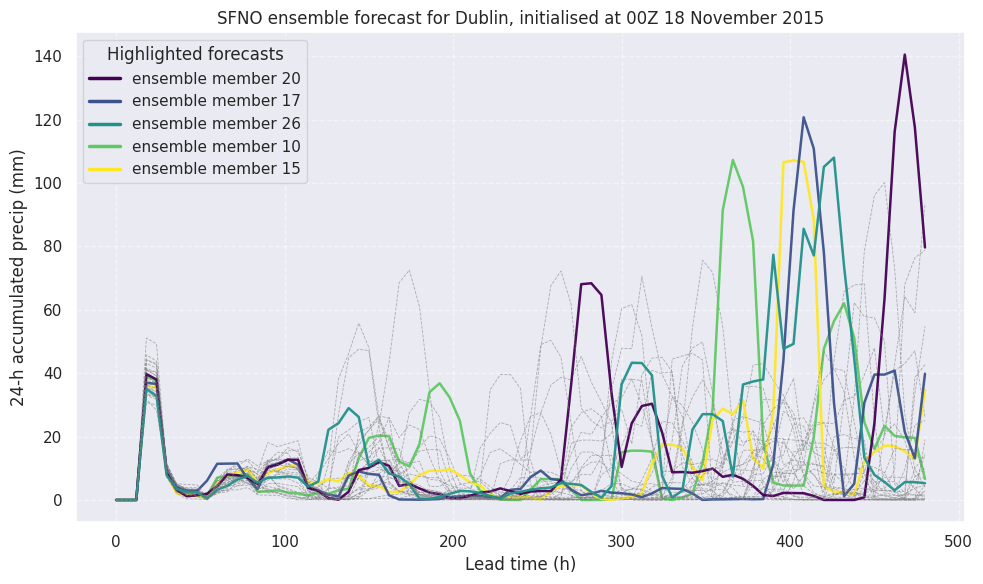

In [18]:
metric = '24h-sum'
date_expr = events[event_str]['date_expr']
ds = da_plot

fig, ax = plt.subplots(figsize=(10,6))

# if input file contains a MultiIndex, i.e. we have stacked seed x ensemble ('Desmond')
if event_str == 'Desmond':
    for i,(s,m) in enumerate(sample_index):
        x = ds.lead_time.values
        y = ds.isel(member=i).values
        if int(s) in top5_member_inds:
            ax.plot(x, y, color=top5_member_colours[int(s)], lw=1.8, alpha=0.95)
        else:
            ax.plot(x, y, color='gray', lw=0.6, linestyle='--', alpha=0.6)
# if we haven't run the 'stack' command on the input file ('Desmond_seed76')
elif event_str == 'Desmond_seed76' or event_str == 'Desmond_seed76_v2':
    for i, ens in enumerate(sample_index):
        x = ds.lead_time.values
        y = ds.isel(member=i).values
        if int(ens) in top5_member_inds:
            ax.plot(x, y, color=top5_member_colours[int(ens)], lw=1.8, alpha=0.95)
        else:
            ax.plot(x, y, color='gray', lw=0.6, linestyle='--', alpha=0.6)

# add background grid 
ax.grid(True, linestyle='--', alpha=0.5)

# legend per highlighted seed 
# optionally add one legend entry per highlighted seed (avoid crowding)
handles, labels = ax.get_legend_handles_labels()
# If too many individual member labels appear, build a single legend per seed:
from matplotlib.lines import Line2D
legend_handles = []
legend_labels = []
for s in top5_member_inds:
    legend_handles.append(Line2D([0],[0], color=top5_member_colours[s], lw=2.5))
    if event_str == 'Desmond_seed76' or event_str == 'Desmond_seed76_v2':
        legend_labels.append(f'ensemble member {s}')
    else:
        legend_labels.append(f'seed {s}')
if event_str == 'Desmond_seed76' or event_str == 'Desmond_seed76_v2':
    ax.legend(legend_handles, legend_labels, title='Highlighted forecasts', loc='best')
else:
    ax.legend(legend_handles, legend_labels, title='Highlighted seeds', loc='best')

# other formatting and axis labelling 
ax.set_xlabel('Lead time (h)')
ax.set_ylabel('24-h accumulated precip (mm)')
ax.set_title(f'SFNO ensemble forecast for {location}, initialised at {date_expr}')
plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_{date_str}_SFNO_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Original plotting structure

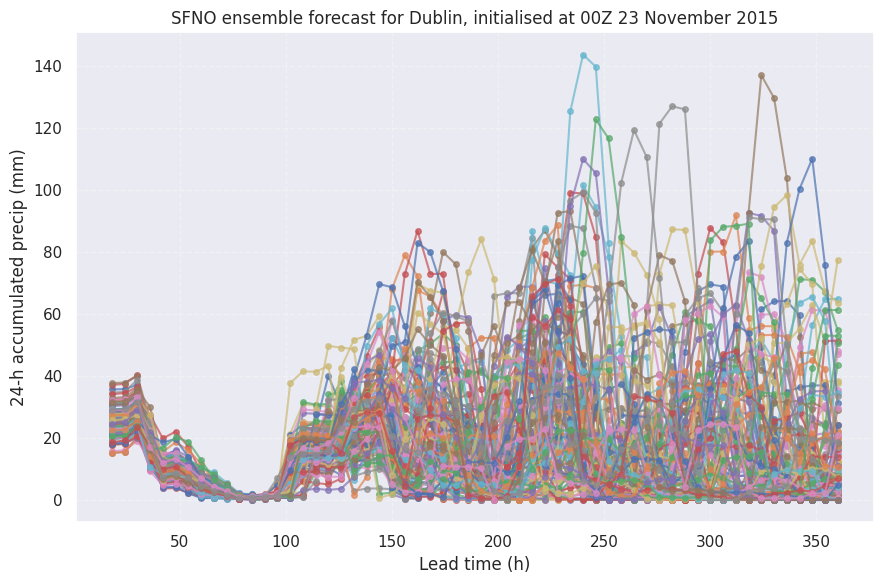

In [28]:
fig, ax = plt.subplots(figsize=(9,6))
metric = '24h-sum'
da_pr24 = da_pr_all.rolling(lead_time=4,min_periods=4).sum().dropna('lead_time')
num_fcsts = len(da_pr24.member.values)
date_expr = events[event_str]['date_expr']

if metric == '24h-sum':
    ds = da_pr24.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
elif metric == '24h-mean':
    ds = da_pr24.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])
for fcst in range(num_fcsts):
    ax.plot(ds.lead_time.values, 
            ds.isel(member=fcst), 
            marker='o', ms=4, alpha=0.7)

# add background grid 
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlabel('Lead time (h)')
ax.set_ylabel('24-h accumulated precip (mm)')
ax.set_title(f'SFNO ensemble forecast for {location}, initialised at {date_expr}')
plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_{date_str}_SFNO_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Plot the 6-h rainfall from the SFNO ensemble forecast 

- 34 `checkpoints` x 4 `seeds` --> 136 ensemble members 
- Forecast initialised at 00Z on 23 November 2015 (Desmond)

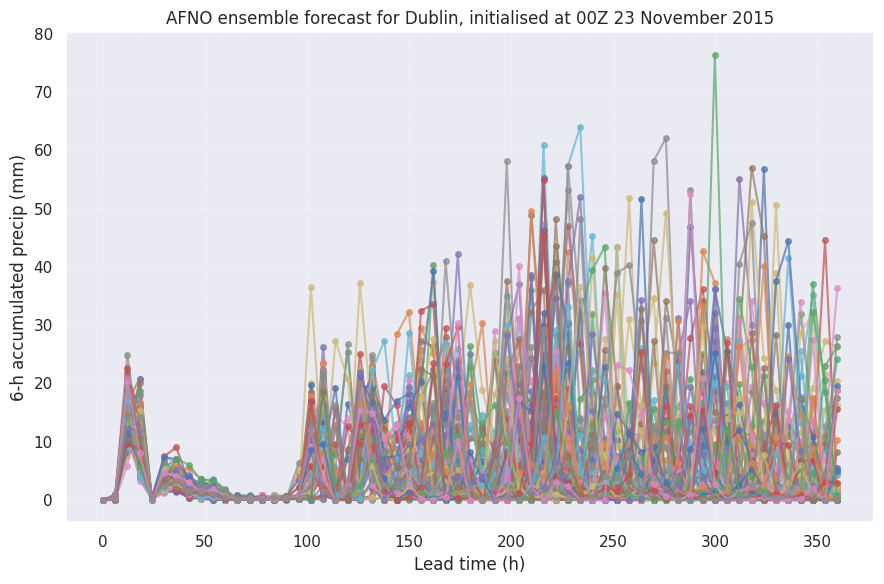

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
metric = '6h-sum'
date_expr = events[event_str]['date_expr']

for file in files:
    ds = xr.open_dataset(file)
    seed_str = file.split('/')[5].split('_')[1].split('.')[0] # extract the seed number from the file path 
    ds = normalise_longitude(ds, lon_name='lon')
    if metric == '6h-sum':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
    elif metric == '6h-mean':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])
    ds['tp06'] = ds['tp06'] * 1000.0
    for ens in ds.ensemble:
        ax.plot(ds.lead_time.values, 
                ds.sel(ensemble=ens)['tp06'], 
                marker='o', ms=4, alpha=0.7)

# add background grid 
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlabel('Lead time (h)')
ax.set_ylabel('6-h accumulated precip (mm)')
ax.set_title(f'AFNO ensemble forecast for {location}, initialised at {date_expr}')
plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_{date_str}_AFNO_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Repeat for cumulative precip plot (6-h)

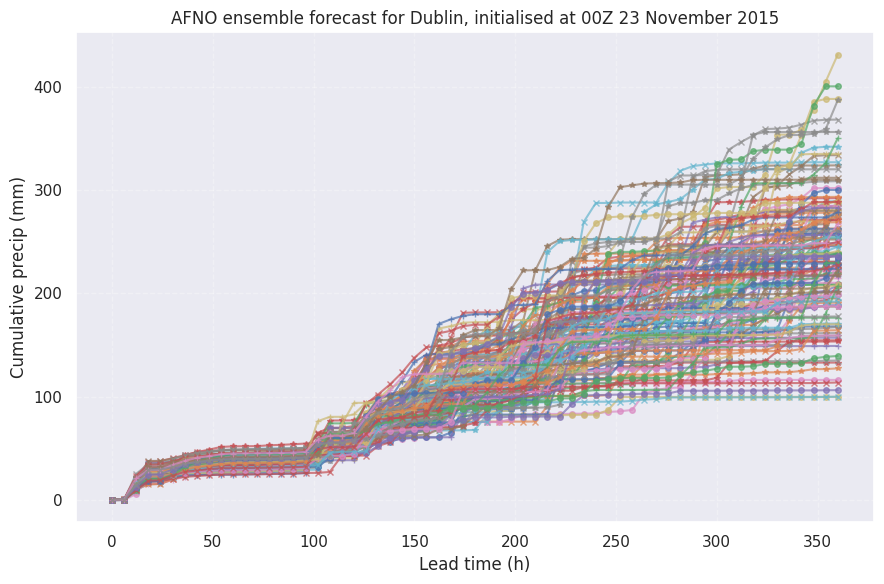

In [35]:
fig, ax = plt.subplots(figsize=(9,6))
metric = '6h-sum'

for file in files:
    ds = xr.open_dataset(file)
    seed_str = file.split('/')[5].split('_')[1].split('.')[0] # extract the seed number from the file path 
    ds = normalise_longitude(ds, lon_name='lon')
    if metric == '6h-sum':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
    elif metric == '6h-mean':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])
    ds['tp06'] = ds['tp06'] * 1000.0
    # plot cumulative precipitation over the 3 x 3 grid box 
    markers = ['o','*','+','x']
    for ind, ens in enumerate(ds.ensemble.values):
        cumulative_pr = ds.sel(ensemble=ens)['tp06'].cumsum(dim='lead_time')
        ax.plot(ds.lead_time.values, 
                cumulative_pr, 
                marker=markers[ind], ms=4, alpha=0.7)

# add background grid 
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlabel('Lead time (h)')
ax.set_ylabel('Cumulative precip (mm)')
ax.set_title(f'AFNO ensemble forecast for {location}, initialised at {date_expr}')
plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_{date_str}_AFNO_cumulative_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Plot lagged ensemble forecasts on a single axis  

- Relevant to some additional runs for Desmond (December 2015) that Ash has run 
- Data are on s3: `s3://jba-stress-testing/event_response/global/`
- Not relevant for events other than Desmond (i.e. the non-event in August 2015 and TC Charley, August 1986)

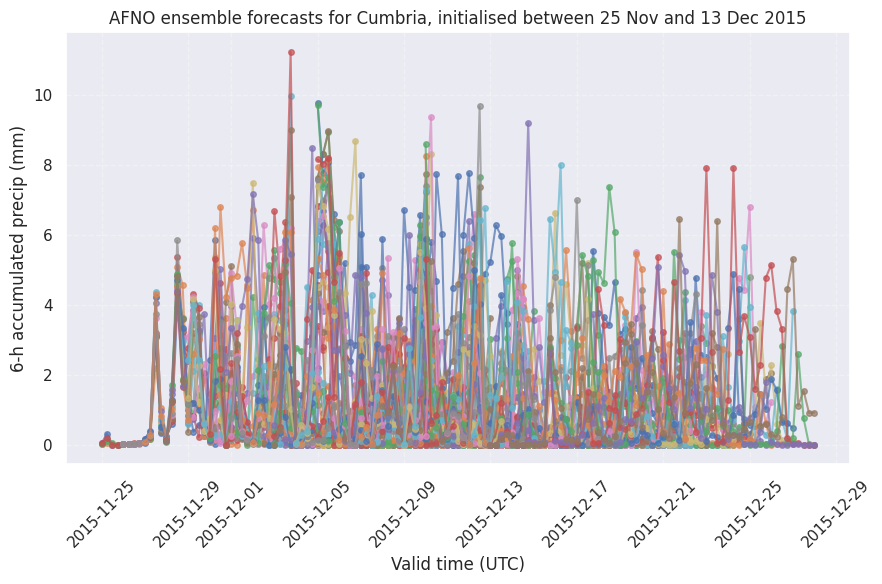

In [11]:
fig, ax = plt.subplots(figsize=(9,6))
metric = 'mean'

file_path = f'/mnt/data/sfno/{event_str}/event_response/' # change to f'/mnt/data/sfno/{event_str}/' if needed 
files = sorted(glob.glob(f'{file_path}/*.nc'))

for file in files:
    ds = xr.open_dataset(file)

    # 1) Get initialisation time (try dataset coordinate first, then filename, then fallback)
    if 'time' in ds.coords:
        # ds.time might be a length-1 array
        init_time = pd.to_datetime(ds['time'].values[0])
    else:
        # try to parse an ISO datetime like "2015-11-25T00" in the filename
        m = re.search(r'(\d{4}-\d{2}-\d{2}T\d{2})', file)
        if m:
            init_time = pd.to_datetime(m.group(1))
        elif date_str:
            init_time = pd.to_datetime(date_str)
        else:
            raise RuntimeError(f"Could not determine init time from {file}")

    # 2) Preprocess and reduce spatial dims (keep lead_time and ensemble)
    ds = normalise_longitude(ds, lon_name='lon')
    if metric == 'sum':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
    elif metric == 'mean':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])
    ds['tp06'] = ds['tp06'] * 1000.0

    # 3) Build an array of valid datetimes: init_time + lead_time (lead_time in hours)
    # adapt if lead_time is already a timedelta-like object
    lead = ds['lead_time'].values
    if np.issubdtype(lead.dtype, np.timedelta64):
        valid_times = pd.to_datetime(lead + np.datetime64(init_time))
    else:
        # assume numeric hours
        valid_times = init_time + pd.to_timedelta(lead.astype(float), unit='h')

    # 4) Plot each ensemble member, label only once per init to avoid huge legends
    for i, ens in enumerate(ds.ensemble.values):
        label = init_time.strftime('%Y-%m-%d %H:%M') if i == 0 else None
        ax.plot(valid_times, ds.sel(ensemble=ens)['tp06'].values,
                marker='o', ms=4, alpha=0.7, label=label)

# Formatting the date axis and legend
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel('Valid time (UTC)')
ax.set_ylabel('6-h accumulated precip (mm)')
ax.set_title(f'AFNO ensemble forecasts for {location}, initialised between 25 Nov and 13 Dec 2015')

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
#ax.legend(title='Init time', fontsize='small', ncol=2, loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_event_response_AFNO_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Repeat for cumulative precip

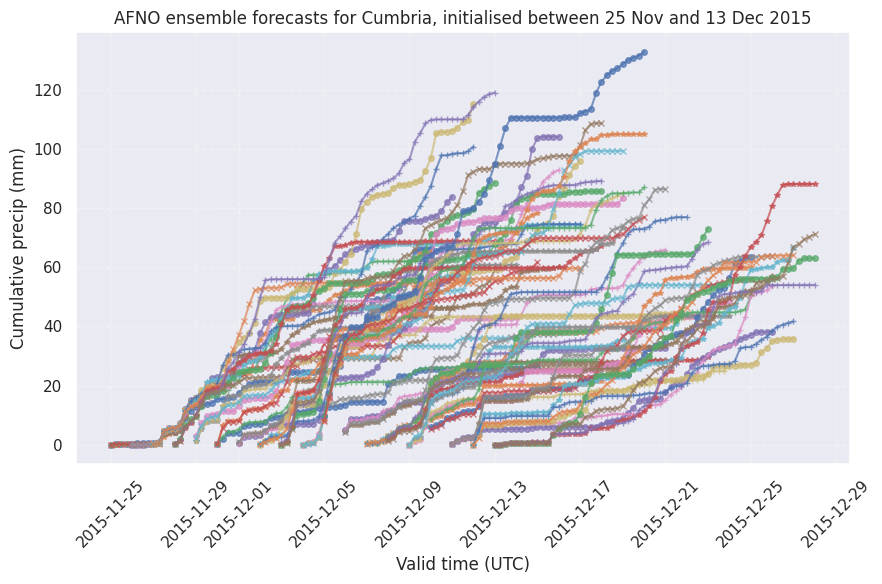

In [12]:
fig, ax = plt.subplots(figsize=(9,6))
metric = 'mean'

file_path = f'/mnt/data/sfno/{event_str}/event_response/' # change to f'/mnt/data/sfno/{event_str}/' if needed 
files = sorted(glob.glob(f'{file_path}/*.nc'))

for file in files:
    ds = xr.open_dataset(file)

    # 1) Get initialisation time (try dataset coordinate first, then filename, then fallback)
    if 'time' in ds.coords:
        # ds.time might be a length-1 array
        init_time = pd.to_datetime(ds['time'].values[0])
    else:
        # try to parse an ISO datetime like "2015-11-25T00" in the filename
        m = re.search(r'(\d{4}-\d{2}-\d{2}T\d{2})', file)
        if m:
            init_time = pd.to_datetime(m.group(1))
        elif date_str:
            init_time = pd.to_datetime(date_str)
        else:
            raise RuntimeError(f"Could not determine init time from {file}")

    # 2) Preprocess and reduce spatial dims (keep lead_time and ensemble)
    ds = normalise_longitude(ds, lon_name='lon')
    if metric == 'sum':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).sum(dim=['lat','lon'])
    elif metric == 'mean':
        ds = ds.squeeze(dim='time').sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1)).mean(dim=['lat','lon'])
    ds['tp06'] = ds['tp06'] * 1000.0

    # 3) Build an array of valid datetimes: init_time + lead_time (lead_time in hours)
    # adapt if lead_time is already a timedelta-like object
    lead = ds['lead_time'].values
    if np.issubdtype(lead.dtype, np.timedelta64):
        valid_times = pd.to_datetime(lead + np.datetime64(init_time))
    else:
        # assume numeric hours
        valid_times = init_time + pd.to_timedelta(lead.astype(float), unit='h')

    # cumulative precip
    markers = ['o','*','+','x']
    for ind, ens in enumerate(ds.ensemble.values):
        label = init_time.strftime('%Y-%m-%d %H:%M') if ind == 0 else None
        cumulative_pr = ds.sel(ensemble=ens)['tp06'].cumsum(dim='lead_time')
        ax.plot(valid_times, 
                cumulative_pr,
                marker=markers[ind], ms=4, alpha=0.7, label=label)

# Formatting the date axis and legend
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel('Valid time (UTC)')
ax.set_ylabel('Cumulative precip (mm)')
ax.set_title(f'AFNO ensemble forecasts for {location}, initialised between 25 Nov and 13 Dec 2015')

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
#ax.legend(title='Init time', fontsize='small', ncol=2, loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{lat0}N_{lat1}N_{lon0}W_{lon1}W_event_response_AFNO_cumulative_precip_{metric}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Identify the most extreme ensemble member

- TODO: modify this code to pull out the top 5 or 10 ensemble-lead time combinations (could then produce equivalent panels plots for these extra dates)

In [21]:
best = {'value': 0}  # will store best peak info

for file in files:
    ds = xr.open_dataset(file)
    seed_str = file.split('/')[5].split('_')[1].split('.')[0] # extract the seed number from the file path (for regular ensemble input files) 
    #seed_str = file.split('/')[6].split('_')[2].split('.')[0] # for 'event_response' input files 
    print(seed_str)
    print(f'Working on file: {file}')
    ds = normalise_longitude(ds, lon_name='lon')

    # select and collapse space and time 
    ds = (ds.squeeze(dim='time')
            .sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1))
            .sum(dim=['lat', 'lon']))
    ds['tp06'] = ds['tp06'] * 1000.0  # convert to mm

    # per-ensemble peak (max over lead_time)
    peak_per_ens = ds['tp06'].max(dim='lead_time')  # DataArray indexed by ensemble

    # highest peak in this file and which ensemble index it is
    file_peak_value = float(peak_per_ens.max().item())
    ens_idx = int(peak_per_ens.argmax(dim='ensemble').item())
    ens_coord = peak_per_ens['ensemble'].values[ens_idx]

    # the lead_time at which that ensemble reaches its peak
    lead_of_peak = ds['tp06'].isel(ensemble=ens_idx).idxmax(dim='lead_time').item()

    # print relevant information 
    #print(file_peak_value, ens_idx, lead_of_peak)

    if file_peak_value > best['value']:
        best = {
            'value': file_peak_value,
            'seed': seed_str,
            'file': file,
            'ensemble_index': ens_idx,
            'ensemble_coord': ens_coord,
            'lead_time_of_peak': lead_of_peak,
            'ts': ds.isel(ensemble=ens_idx)
        }

# report best
print("Best peak (mm):", best['value'])
print("Seed:", best['seed'])
print("Ensemble coord:", best['ensemble_coord'])
print("Lead time of peak:", best['lead_time_of_peak'])
print("File:", best['file'])
# best['ts'] contains the space-summed time series (tp06 vs lead_time) for that ensemble

seed102
Working on file: /mnt/data/sfno/Desmond/Desmond_seed102.nc
seed103
Working on file: /mnt/data/sfno/Desmond/Desmond_seed103.nc
seed105
Working on file: /mnt/data/sfno/Desmond/Desmond_seed105.nc
seed106
Working on file: /mnt/data/sfno/Desmond/Desmond_seed106.nc
seed108
Working on file: /mnt/data/sfno/Desmond/Desmond_seed108.nc
seed12
Working on file: /mnt/data/sfno/Desmond/Desmond_seed12.nc


seed16
Working on file: /mnt/data/sfno/Desmond/Desmond_seed16.nc
seed17
Working on file: /mnt/data/sfno/Desmond/Desmond_seed17.nc
seed18
Working on file: /mnt/data/sfno/Desmond/Desmond_seed18.nc
seed26
Working on file: /mnt/data/sfno/Desmond/Desmond_seed26.nc
seed27
Working on file: /mnt/data/sfno/Desmond/Desmond_seed27.nc
seed28
Working on file: /mnt/data/sfno/Desmond/Desmond_seed28.nc
seed29
Working on file: /mnt/data/sfno/Desmond/Desmond_seed29.nc
seed30
Working on file: /mnt/data/sfno/Desmond/Desmond_seed30.nc
seed70
Working on file: /mnt/data/sfno/Desmond/Desmond_seed70.nc
seed71
Working on file: /mnt/data/sfno/Desmond/Desmond_seed71.nc
seed72
Working on file: /mnt/data/sfno/Desmond/Desmond_seed72.nc
seed74
Working on file: /mnt/data/sfno/Desmond/Desmond_seed74.nc
seed76
Working on file: /mnt/data/sfno/Desmond/Desmond_seed76.nc
seed77
Working on file: /mnt/data/sfno/Desmond/Desmond_seed77.nc
seed78
Working on file: /mnt/data/sfno/Desmond/Desmond_seed78.nc
seed80
Working on file: /

## Produce a spatial plot of the most extreme ensemble member

- TODO: sync the choice of input file with the cell above

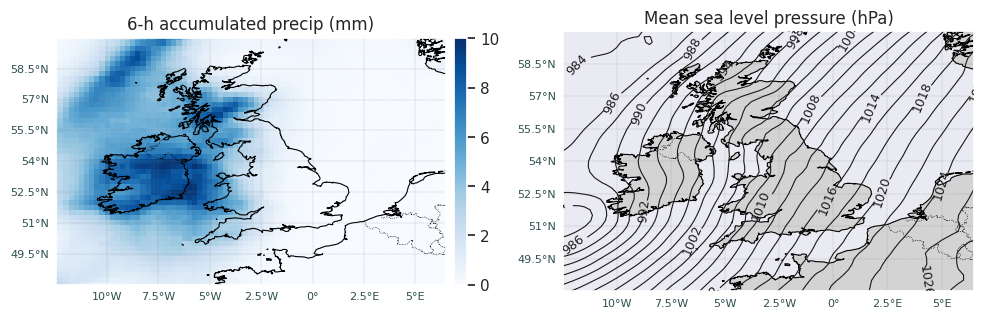

In [ ]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
crs = ccrs.PlateCarree()
extent = [-12.5, 6.5, 48.0, 60.0]  # [lon_min, lon_max, lat_min, lat_max]

# values corresponding to the ensemble member with most extreme rainfall 
""" 
August 2015 'non-event':
    21T00: ens0, T+108, seed72
    20T00: ens
    15T00: ens2, T+228, seed72
    ?????: ens0, T+54, seed86 (120 mm); file path = `/mnt/data/sfno/21Aug2015/ireland_uk_seed86.nc`
Desmond ensemble initialised on 23 Nov 2015: 
    Dublin: ens0, T+300, seed76
    Cumbria: ens1, T+216, seed29
Desmond consecutive runs: 
    Dublin: ens2, T+12, seed12, 2015-12-03T00
    Cumbria: ens1, T+18, seed12, 2025-12-03T00
"""
location = 'Dublin'
best_ensemble = 0 # 2, 1, 0
best_lead = 300 # 132, 144, 144
best_seed = 76 # 80, 102, 76

# read in data from selected ensemble member and remove singleton dimension
if file_path == '/mnt/data/sfno/Desmond/':
    nc_file = f'{file_path}/{event_str}_seed{best_seed}.nc'
elif file_path == '/mnt/data/sfno/Desmond/event_response/':
    nc_file = f'/mnt/data/sfno/{event_str}/event_response/{event_str}_{date_str}_seed12.nc'
ds = xr.open_dataset(nc_file).squeeze(dim='time')
ds = normalise_longitude(ds, lon_name='lon')

# select ensemble member - allow selecting by label or index
try:
    ds_mem = ds.sel(ensemble=best_ensemble)
except Exception:
    ds_mem = ds.isel(ensemble=int(best_ensemble))

# select the lead_time: try label selection, fall back to isel
try:
    ds_t = ds_mem.sel(lead_time=best_lead)
except Exception:
    ds_t = ds_mem.isel(lead_time=int(best_lead))

# change units of 6-h acc precip from 'm' to 'mm'
ds_t['tp06'] = ds_t['tp06'] * 1000.0

# extract rainfall values and latitude/longitude arrays 
da_prcp = ds_t['tp06']          # DataArray with dims (lat, lon)
da_pmsl = ds_t['msl']
lon = da_prcp['lon'].values
lat = da_prcp['lat'].values
Lon, Lat = np.meshgrid(lon, lat)

# common function to add coastal features
def decorate(ax):
    ax.set_extent(extent, crs=crs)
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', zorder=0)


# create a panel plot with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 6),
                         subplot_kw={'projection': crs})
axes = axes.ravel()

# FIRST PANEL (6-h accumulated precip)
ax = axes[0]
decorate(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
# remove lat-lon labels on top and right axes 
try:
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
except AttributeError:
    gl.xlabels_top = False
    gl.xlabels_bottom = True
    gl.ylabels_right = False
    gl.ylabels_left = True

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# make the lat/lon labels smaller and lighter
gl.xlabel_style = {'size': 8, 'color': 'darkslategray'}
gl.ylabel_style = {'size': 8, 'color': 'darkslategray'}

pcm = ax.pcolormesh(Lon, Lat, da_prcp.values, cmap='Blues', shading='auto', transform=crs)
cb = fig.colorbar(pcm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
ax.set_title('6-h accumulated precip (mm)')


# SECOND PANEL (mean sea level pressure)
ax = axes[1]
decorate(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
# remove lat-lon labels on top and right axes 
try:
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
except AttributeError:
    gl.xlabels_top = False
    gl.xlabels_bottom = True
    gl.ylabels_left = False
    gl.ylabels_right = True

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# make the lat/lon labels smaller and lighter
gl.xlabel_style = {'size': 8, 'color': 'darkslategray'}
gl.ylabel_style = {'size': 8, 'color': 'darkslategray'}

# Convert MSLP to hPa if it's in Pa (common). Check units attribute if available.
p = da_pmsl.values.copy()
units = da_pmsl.attrs.get('units', '').lower()
if 'pa' in units or (p.mean() > 2000):   # heuristic: values >> 1000 probably Pa
    p_hpa = p / 100.0
else:
    p_hpa = p

# make sensible contour levels (e.g. every 2 hPa)
p_min = np.nanmin(p_hpa)
p_max = np.nanmax(p_hpa)
interval = 2.0
levels = np.arange(np.floor(p_min / interval) * interval, np.ceil(p_max / interval) * interval + 1e-6, interval)

# add contour lines (isobars)
cs = ax.contour(Lon, Lat, p_hpa, levels=levels, colors='k', linewidths=0.8, transform=crs)
ax.clabel(cs, inline=True, fmt='%d', fontsize=9)
ax.set_title('Mean sea level pressure (hPa)')

#plt.suptitle(f'Forecast seed {best_seed}, ensemble member {best_ensemble}, lead time T+{best_lead}', fontsize=14, y=0.98)
plt.tight_layout()
out_file = f'/mnt/data/output_plots/{event_str}_{location}_{date_str}_AFNO_precip_mslp_seed{best_seed}_ens{best_ensemble}_T+{best_lead}.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)